In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# === INPUT ===
review_path = "/Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/visual_verification/ltccd_clusters_review.geojson"

# RASTERS from Notebook 2
delta_path = "/Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/rasters/delta_gamma.tif"
zscore_path = "/Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/rasters/z_score.tif"
baseline_mean_path = "/Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/rasters/mean_baseline.tif"
post_mean_path = "/Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/rasters/mean_post.tif"

print("📂 Paths configured")

📂 Paths configured


In [3]:
clusters = gpd.read_file(review_path)

print(f"Clusters loaded: {len(clusters)}")

# фильтруем только размеченные
clusters = clusters[clusters["review_status"].notna()].copy()

print(f"Labeled clusters: {len(clusters)}")
print(clusters["review_status"].value_counts())

Clusters loaded: 180
Labeled clusters: 180
review_status
yes    149
no      31
Name: count, dtype: int64


In [4]:
def extract_stats(raster_path, polygons_gdf):
    values = []

    with rasterio.open(raster_path) as src:
        for geom in polygons_gdf.geometry:
            try:
                out_image, _ = mask(src, [geom], crop=True)
                data = out_image[0]

                data = data[~np.isnan(data)]

                if len(data) == 0:
                    values.append(np.nan)
                else:
                    values.append(np.nanmean(data))

            except:
                values.append(np.nan)

    return np.array(values)

In [5]:
print("📊 Extracting raster statistics...")

clusters["delta_mean"] = extract_stats(delta_path, clusters)
clusters["zscore_mean"] = extract_stats(zscore_path, clusters)
clusters["baseline_mean"] = extract_stats(baseline_mean_path, clusters)
clusters["post_mean"] = extract_stats(post_mean_path, clusters)

print("✅ Metrics extracted")

📊 Extracting raster statistics...
✅ Metrics extracted


In [6]:
# positive class
destruction = clusters[clusters["review_status"] == "yes"]

# negative class (всё остальное)
non_destruction = clusters[clusters["review_status"] != "yes"]

print(f"Destruction: {len(destruction)}")
print(f"Other: {len(non_destruction)}")

Destruction: 149
Other: 31


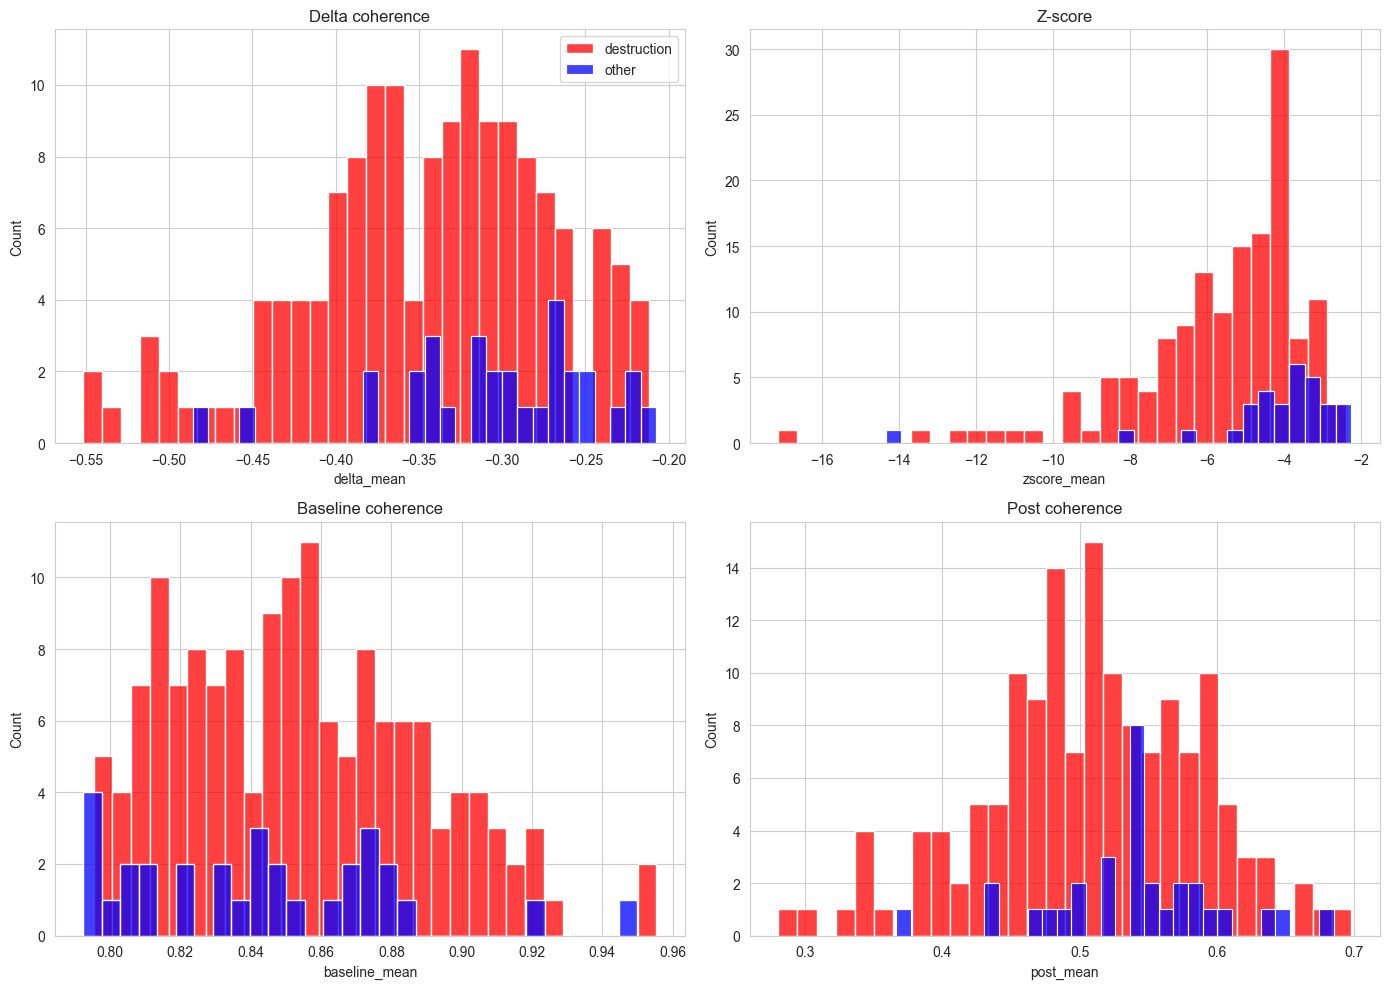

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# DELTA
sns.histplot(destruction["delta_mean"], color="red", label="destruction", ax=axes[0,0], bins=30)
sns.histplot(non_destruction["delta_mean"], color="blue", label="other", ax=axes[0,0], bins=30)
axes[0,0].set_title("Delta coherence")
axes[0,0].legend()

# Z-SCORE
sns.histplot(destruction["zscore_mean"], color="red", ax=axes[0,1], bins=30)
sns.histplot(non_destruction["zscore_mean"], color="blue", ax=axes[0,1], bins=30)
axes[0,1].set_title("Z-score")

# BASELINE
sns.histplot(destruction["baseline_mean"], color="red", ax=axes[1,0], bins=30)
sns.histplot(non_destruction["baseline_mean"], color="blue", ax=axes[1,0], bins=30)
axes[1,0].set_title("Baseline coherence")

# POST
sns.histplot(destruction["post_mean"], color="red", ax=axes[1,1], bins=30)
sns.histplot(non_destruction["post_mean"], color="blue", ax=axes[1,1], bins=30)
axes[1,1].set_title("Post coherence")

plt.tight_layout()
plt.show()

ValueError: List of boxplot statistics and `positions` values must have same the length

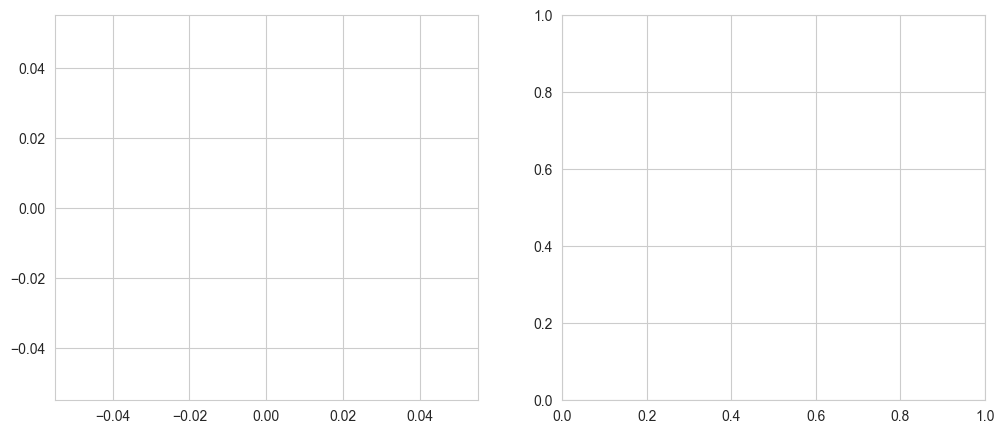

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=clusters, x="review_type", y="delta_mean", ax=axes[0])
axes[0].set_title("Delta by class")

sns.boxplot(data=clusters, x="review_type", y="zscore_mean", ax=axes[1])
axes[1].set_title("Z-score by class")

plt.xticks(rotation=30)
plt.show()

In [ ]:
summary = clusters.groupby("review_type").agg({
    "delta_mean": ["mean", "std"],
    "zscore_mean": ["mean", "std"],
    "baseline_mean": ["mean"],
    "post_mean": ["mean"]
})

print("📊 Summary statistics:")
display(summary)

📊 Summary statistics:


delta_mean           zscore_mean           baseline_mean post_mean
                  mean       std        mean       std          mean      mean
review_type                                                                   
destruction  -0.358114  0.063065   -6.189486  2.504023      0.852551  0.494438
no           -0.322278  0.066523   -4.724538  1.765396      0.848905  0.526627

: 

: 

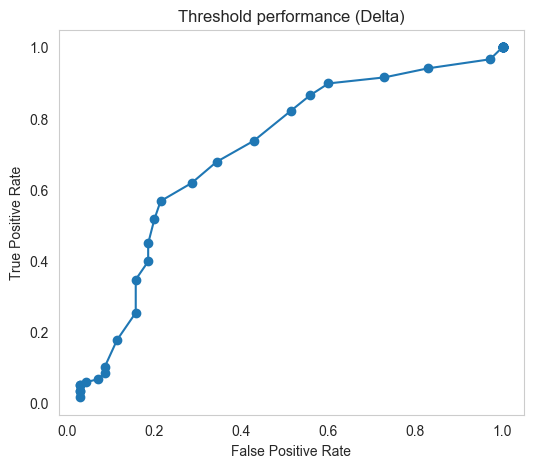

: 

: 

In [ ]:
thresholds = np.linspace(-0.5, 0.0, 50)

results = []

for t in thresholds:
    tp = np.sum(destruction["delta_mean"] < t)
    fn = np.sum(destruction["delta_mean"] >= t)

    fp = np.sum(non_destruction["delta_mean"] < t)
    tn = np.sum(non_destruction["delta_mean"] >= t)

    tpr = tp / (tp + fn + 1e-6)
    fpr = fp / (fp + tn + 1e-6)

    results.append((t, tpr, fpr))

df_thr = pd.DataFrame(results, columns=["threshold", "TPR", "FPR"])

plt.figure(figsize=(6,5))
plt.plot(df_thr["FPR"], df_thr["TPR"], marker="o")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Threshold performance (Delta)")
plt.grid()
plt.show()